# Corrective RAG (CRAG)

**Flow:** `retrieve -> grade each document -> if any are irrelevant: rewrite the query and
search the web to fill the gap -> generate`

Unlike the agent in `1_Agentic_RAG.ipynb`, this pipeline always retrieves first — there's
no "should I retrieve?" decision. What's "corrective" about it is what happens *after*
retrieval: every retrieved chunk is graded for relevance, and if any chunk fails the
grade, the pipeline automatically rewrites the question and falls back to a live web
search (via Tavily) to patch the gap before generating an answer.

Run the cells top to bottom. You'll need `GROQ_API_KEY` and `TAVILY_API_KEY` — see the
README for setup with `uv`.


## 1. Imports

In [29]:
import os
from dotenv import load_dotenv
from IPython.display import Image, display
import requests
from bs4 import BeautifulSoup
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import (
    BaseMessage,
    AnyMessage,
    HumanMessage,
    AIMessage,
    SystemMessage
)
from langchain_core.output_parsers import StrOutputParser
from typing import Annotated, get_type_hints, List
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from typing import Literal
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate


## 2. Load API keys
This notebook additionally needs `TAVILY_API_KEY` for the web-search fallback.

In [28]:
load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

## 3. Initialize the LLM

In [3]:
groq_llm = ChatGroq(
    api_key=GROQ_API_KEY,
    model="openai/gpt-oss-120b",
    temperature=0
)

## 4. Scrape the source documents
Here the knowledge base is Lilian Weng's blog posts on agents, prompt engineering, and adversarial attacks on LLMs — a single knowledge base this time (compare to the two separate stores in notebook 1).

In [4]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = []

headers = {"User-Agent": "Mozilla/5.0"}

for url in urls:
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")
    
    title = soup.title.string.strip() if soup.title else "No title"
    text = soup.get_text(separator="\n", strip=True)
    
    docs.append({"source": url, "title": title, "text": text})

In [5]:
docs

[{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
  'title': "LLM Powered Autonomous Agents | Lil'Log",
  'text': 'LLM Powered Autonomous Agents | Lil\'Log\nLil\'Log\n|\nPosts\nArchive\nSearch\nTags\nFAQ\nLLM Powered Autonomous Agents\nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\nTable of Contents\nAgent System Overview\nComponent One: Planning\nTask Decomposition\nSelf-Reflection\nComponent Two: Memory\nTypes of Memory\nMaximum Inner Product Search (MIPS)\nComponent Three: Tool Use\nCase Studies\nScientific Discovery Agent\nGenerative Agents Simulation\nProof-of-Concept Examples\nChallenges\nCitation\nReferences\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as\nAutoGPT\n,\nGPT-Engineer\nand\nBabyAGI\n, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a

## 5. Wrap pages as `Document` objects and chunk them
1000-character chunks with 200 characters of overlap, same splitter settings as notebook 1.

In [6]:
documents = []

for doc in docs:
    document = Document(
        page_content=doc["text"],
        metadata={"source": doc["source"], "title": doc["title"]}
    )
    documents.append(document)
    
documents

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log"}, page_content='LLM Powered Autonomous Agents | Lil\'Log\nLil\'Log\n|\nPosts\nArchive\nSearch\nTags\nFAQ\nLLM Powered Autonomous Agents\nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\nTable of Contents\nAgent System Overview\nComponent One: Planning\nTask Decomposition\nSelf-Reflection\nComponent Two: Memory\nTypes of Memory\nMaximum Inner Product Search (MIPS)\nComponent Three: Tool Use\nCase Studies\nScientific Discovery Agent\nGenerative Agents Simulation\nProof-of-Concept Examples\nChallenges\nCitation\nReferences\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as\nAutoGPT\n,\nGPT-Engineer\nand\nBabyAGI\n, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; i

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

## 6. Create the embedding model
Same local `BAAI/bge-m3` model used throughout this repo, so results stay comparable across notebooks.

In [8]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    show_progress=True,
    encode_kwargs={"batch_size": 32}
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

## 7. Build the vector store

In [11]:
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    collection_name="docs"
)

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

## 8. Sanity-check a stored record

In [12]:
collection = vectorstore._collection

print("Collection name:", collection.name)
print("Record count:", collection.count())

data = collection.get(
    limit=1,
    include=["embeddings", "documents", "metadatas"]
)

print("\n--- RECORD ---")

print("\nID:")
print(data["ids"][0])

print("\nDocument:")
print(data["documents"][0])

print("\nMetadata:")
print(data["metadatas"][0])

print("\nEmbedding:")
print(data["embeddings"][0])

Collection name: docs
Record count: 162

--- RECORD ---

ID:
594124d0-2e5d-487c-aa78-6d2430e6e178

Document:
LLM Powered Autonomous Agents | Lil'Log
Lil'Log
|
Posts
Archive
Search
Tags
FAQ
LLM Powered Autonomous Agents
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng
Table of Contents
Agent System Overview
Component One: Planning
Task Decomposition
Self-Reflection
Component Two: Memory
Types of Memory
Maximum Inner Product Search (MIPS)
Component Three: Tool Use
Case Studies
Scientific Discovery Agent
Generative Agents Simulation
Proof-of-Concept Examples
Challenges
Citation
References
Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as
AutoGPT
,
GPT-Engineer
and
BabyAGI
, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview
#


## 9. Create the retriever
Top-3 chunks per query this time.

In [22]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

## 10. Quick manual retrieval test

In [45]:
retriever.invoke("what is agent memory")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Document(id='7f78dff2-29f5-4361-a9a3-d5e3b6872ff3', metadata={'title': "LLM Powered Autonomous Agents | Lil'Log", 'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Agent System Overview\n#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\nPlanning\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\nMemory\nShort-term memory: I would consider all the in-context learning (See\nPrompt Engineering\n) as utilizing short-term memory of the model to learn.\nLong-term memory: This provides the agent with the capability to retain and recall (infinite) information over extended periods, often by leveraging a

## 11. Document relevance grader
A structured-output LLM call that scores each retrieved chunk `yes`/`no` for relevance — this is the check that decides whether correction is needed.

In [ ]:
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )
    
structured_llm_grader = groq_llm.with_structured_output(GradeDocuments)

In [26]:
grade_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template("""Decide whether a retrieved passage is actually useful for answering a question. \n 
        Count it as relevant if it overlaps with the question either in specific keywords or in overall meaning. \n
        Reply with only 'yes' or 'no'."""),

        HumanMessagePromptTemplate.from_template("Retrieved passage: \n\n {document} \n\n Question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
retrieval_grader.invoke({"question": question, "document": doc_txt})


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

GradeDocuments(binary_score='yes')

## 12. Generation chain
A plain RAG answer chain: retrieved context + question in, a concise answer out. Tested here directly before it's wired into the graph.

In [27]:
prompt = ChatPromptTemplate.from_template(
    """ 
    Answer the question using only the context provided below.
    If the context doesn't give you enough to answer, say you don't know instead of guessing.
    Keep the answer to three sentences or fewer.

    Question: {question}
    Context: {context}
    Answer:
    """
    )

rag_chain = prompt | groq_llm | StrOutputParser()

generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

Agent memory consists of two layers: short‑term memory uses the model’s in‑context learning to retain recent prompts and responses, while long‑term memory stores experiences in an external vector store or database that can be retrieved later. In generative agents, this long‑term store is a “memory stream” of natural‑language observations, and a retrieval model surfaces the most relevant, recent, or important entries to guide behavior. Together, these mechanisms let the agent recall past actions and refine future decisions.


## 13. Question rewriter
If the retrieved documents aren't good enough, this chain reformulates the question to be a better *web search* query — different phrasing works better for a search engine than for a vector similarity match.

In [31]:
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        SystemMessagePromptTemplate.from_template(
            """Rephrase the question that follows into a version better suited to a web search engine. \n 
     Think about what the person is actually trying to find out, then write a search-friendly query that captures that intent."""
        ),
        HumanMessagePromptTemplate.from_template(
            "Original question: \n\n {question} \n Write an improved, search-friendly version."
        ),
    ]
)

question_rewriter = re_write_prompt | groq_llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'**Improved search‑optimized question:**  \n*What is “agent memory” in artificial intelligence, and what types or mechanisms do AI agents use to store and retrieve information during decision‑making?*'

## 14. Web search fallback (Tavily)
The correction mechanism: when local documents fail the relevance grade, this function searches the live web and returns formatted snippets to feed into generation.

In [61]:
tavily_client = TavilySearch(
    max_results=5,
    topic="general",
    tavily_api_key=TAVILY_API_KEY,
)


def tavily_search(query: str) -> str:
    """Search the web using Tavily and return titles, URLs, and content snippets."""
    try:
        response = tavily_client.invoke({"query": query})
    except Exception as e:
        return f"Tavily exception: {e}"

    results = response.get("results", [])

    docs = []
    for r in results:
        doc = (
            f"Title: {r.get('title', '')}\n"
            f"URL: {r.get('url', '')}\n"
            f"Content: {r.get('content', '')[:500]}"
        )
        docs.append(doc)

    if docs:
        return "\n\n".join(docs)
    else:
        return "No results found."

## 15. Define the graph state
Tracks the question, the current documents, a `web_search` yes/no flag set by the grader, and the final generation.

In [62]:
class State(BaseModel):

    question: str
    generation: str = ""
    web_search: str = ""
    documents: List[Document] = ""

## 16. Define the graph nodes
- `retrieve` — pull chunks from the vector store
- `grade_documents` — score each chunk; flip `web_search` to `"Yes"` if any chunk fails
- `transform_query` — rewrite the question for web search
- `web_search` — append fresh web results to the documents
- `generate` — answer from whatever documents ended up relevant
- `decide_to_generate` — the branch point: straight to `generate`, or detour through correction first

In [71]:
def retrieve(state: State):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state.question

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state: State):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state.question
    documents = state.documents

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state.question
    documents = state.documents

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state.question
    documents = state.documents

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state.question
    documents = state.documents

    # Web search
    query = question
    web_results_text = tavily_search(question)

    web_results = Document(page_content=web_results_text)
    documents.append(web_results)

    return {"documents": documents, "question": question}




def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    
    web_search = state.web_search

    if web_search == "Yes":

        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        print("---DECISION: GENERATE---")
        return "generate"

## 17. Assemble the graph
Notice the shape: `retrieve -> grade_documents` always runs, then it's a fork — either straight to `generate`, or `transform_query -> web_search -> generate` when correction is needed.

In [72]:
workflow = StateGraph(State)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

## 18. Compile and visualize

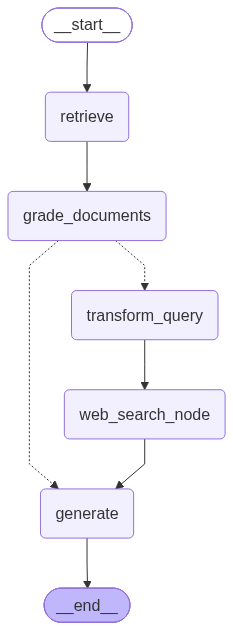

In [73]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## 19. Try it
Ask a question the local knowledge base should cover well.

In [74]:
app.invoke({"question":"What are the types of agent memory?"})

---RETRIEVE---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': '**Improved question:**  \n*What are the different types of memory that can be used by artificial‑intelligence agents (e.g., short‑term, long‑term, episodic, semantic, working, external, etc.)?*',
 'generation': 'AI agents can employ several memory categories that mirror human cognition:  \n\n* **Short‑term / working memory** – the limited, in‑context window used for the current interaction or plan.  \n* **Long‑term memory** – persistent storage (often an external vector store) that survives sessions and can be queried later.  \n\nLong‑term memory is further subdivided into **episodic memory** (chronological records of past events or interactions), **semantic memory** (facts and concepts), **procedural memory** (learned skills or “how‑to” rules), and **external memory** (any off‑model datastore such as databases, files, or knowledge bases).',
 'web_search': 'Yes',
 'documents': [Document(id='7f78dff2-29f5-4361-a9a3-d5e3b6872ff3', metadata={'title': "LLM Powered Autonomous 